# MIMIC-III NLP Tutorial: spaCy vs scispaCy vs medspaCy
### Data Cohort: Subarachnoid Hemorrhage (ICD-9 430) — Discharge Summaries

This notebook demonstrates entity extraction, word2vec embeddings, and tuned t-SNE
visualizations using three NLP libraries applied to real MIMIC-III clinical notes:

1. **spaCy** — general-purpose NLP
2. **scispaCy** — biomedical-domain NLP
3. **medspaCy** — clinical NLP with context/negation detection



## 1. Setup & Installs

In [13]:

!pip install -q --upgrade pip
!pip install -q --upgrade "numpy>=2.0" "gensim>=4.4.0" "scikit-learn>=1.5" matplotlib seaborn


!pip install -q --upgrade spacy


!pip install -q --upgrade scispacy
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz
!pip install -q https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz


!pip install -q --upgrade medspacy

# spacy's small English model
!python -m spacy download en_core_web_sm -q



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scispacy 0.6.2 requires numpy<2.0, but you have numpy 2.5.1 which is incompatible.
en-ner-bc5cdr-md 0.5.4 requires spacy<3.8.0,>=3.7.4, but you have spacy 3.8.14 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
en-ner-bc5cdr-md 0.5.4 requires spacy<3.8.0,>=3.7.4, but you have spacy 3.8.14 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-pytho

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

import spacy
import scispacy
import medspacy
from medspacy.visualization import visualize_ent

from gensim.models import Word2Vec
from sklearn.manifold import TSNE

pd.set_option('display.max_colwidth', 200)
np.random.seed(42)


## 2. Cohort Extraction (BigQuery)

Pull **discharge summaries** for patients diagnosed with **ICD-9 code 430**



In [25]:
# ==========================================
# 2. DATA EXTRACTION & DATA CLEANING
# ==========================================
import pandas as pd
import numpy as np
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()
client = bigquery.Client(project='mc-ut-msai-aih-1')

cohort_query = """
SELECT n.row_id, n.subject_id, n.hadm_id, n.text
FROM `physionet-data.mimiciii_notes.noteevents` n
JOIN (
    SELECT DISTINCT subject_id
    FROM `physionet-data.mimiciii_clinical.diagnoses_icd`
    WHERE icd9_code = '430'
) sah ON n.subject_id = sah.subject_id
WHERE n.category = 'Discharge summary'
"""
df_notes = client.query(cohort_query).to_dataframe()

def clean_clinical_text(text):
    text = re.sub(r'\[\*\*.*?\*\*\]', '', text)  # Strip de-identification blocks
    return re.sub(r'\s+', ' ', text).strip()     # Standardize structural whitespaces

df_notes['clean_text'] = df_notes['text'].apply(clean_clinical_text)
df_sample = df_notes.sample(n=min(100, len(df_notes)), random_state=42).reset_index(drop=True)

---
## 4. spaCy

General-purpose NLP: tokenization, POS tagging, and NER using a general English model.


In [26]:
nlp_spacy = spacy.load("en_core_web_sm")

docs_spacy = list(nlp_spacy.pipe(df_sample['clean_text'].tolist()))

# Look at entities in the first note
for ent in docs_spacy[0].ents:
    print(ent.text, "->", ent.label_)


Admission Date: Discharge Date: Date of Birth -> ORG
No Known Allergies to Drugs Attending -> ORG
Subarachnoid Hemorrhage Major Surgical or Invasive Procedure: Placement -> ORG
Aneurysm History -> PERSON
46 -> CARDINAL
PMH -> ORG
ETOH -> PERSON
this morning -> TIME
15 years ago -> DATE
Family History -> PERSON
66 -> CARDINAL
80s -> DATE
CVA Physical -> ORG
129/76 -> CARDINAL
99% -> PERCENT
2L -> CARDINAL
Gen -> PERSON
Received Ativan -> PERSON
Fentanyl -> PERSON
1 hour -> TIME
Cardiac -> ORG
S1/S2 -> ORG
Extrem -> PERSON
Neuro -> PERSON
5 minutes -> TIME
4 -> CARDINAL
2 mm -> QUANTITY
IV -> GPE
Sternocleidomastoid -> PERSON
XII -> ORG
Reflexes -> ORG
1+ Left -> DATE
URINE BLOOD-NEG -> ORG
12:30PM -> CARDINAL
SMR-NORMAL -> ORG
12:30PM -> CARDINAL
BANDS-0 LYMPHS-9.4 -> DATE
BASOS-0.2 -> ORG
ER -> GPE
ICU -> ORG
Nimodipine -> GPE
the day -> DATE
ICU -> ORG
CIWA -> ORG
10 cm -> QUANTITY
CT -> ORG
ICU -> ORG
CTA/CTP -> ORG
POD#7 -> GPE
Keppra -> NORP
CSF -> ORG
21 days -> DATE
4 weeks -> DA

### 4a. displaCy visualization of entities in one note

In [27]:
from spacy import displacy

displacy.render(docs_spacy[0], style="ent", jupyter=True)


### 4b. Entity extraction across the cohort

In [28]:
spacy_entities = []
for doc in docs_spacy:
    for ent in doc.ents:
        spacy_entities.append({'text': ent.text, 'label': ent.label_})

df_spacy_ents = pd.DataFrame(spacy_entities)
print("Total entities extracted:", len(df_spacy_ents))
df_spacy_ents['label'].value_counts()


Total entities extracted: 12712


,count
label,
CARDINAL,4575
ORG,3969
PERSON,1249
DATE,960
TIME,559
GPE,374
QUANTITY,302
PRODUCT,184
PERCENT,180


### 4c. word2vec on the note corpus

In [29]:
# Tokenize each note into a list of lowercase alphabetic tokens
def tokenize(doc):
    return [t.text.lower() for t in doc if t.is_alpha and not t.is_stop]

spacy_sentences = [tokenize(doc) for doc in docs_spacy]

w2v_spacy = Word2Vec(
    sentences=spacy_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    seed=42,
)
print("Vocab size:", len(w2v_spacy.wv))


Vocab size: 3276


### 4d. Tuned t-SNE

We compare several perplexity values (per the Distill.pub guidance) before settling on one.

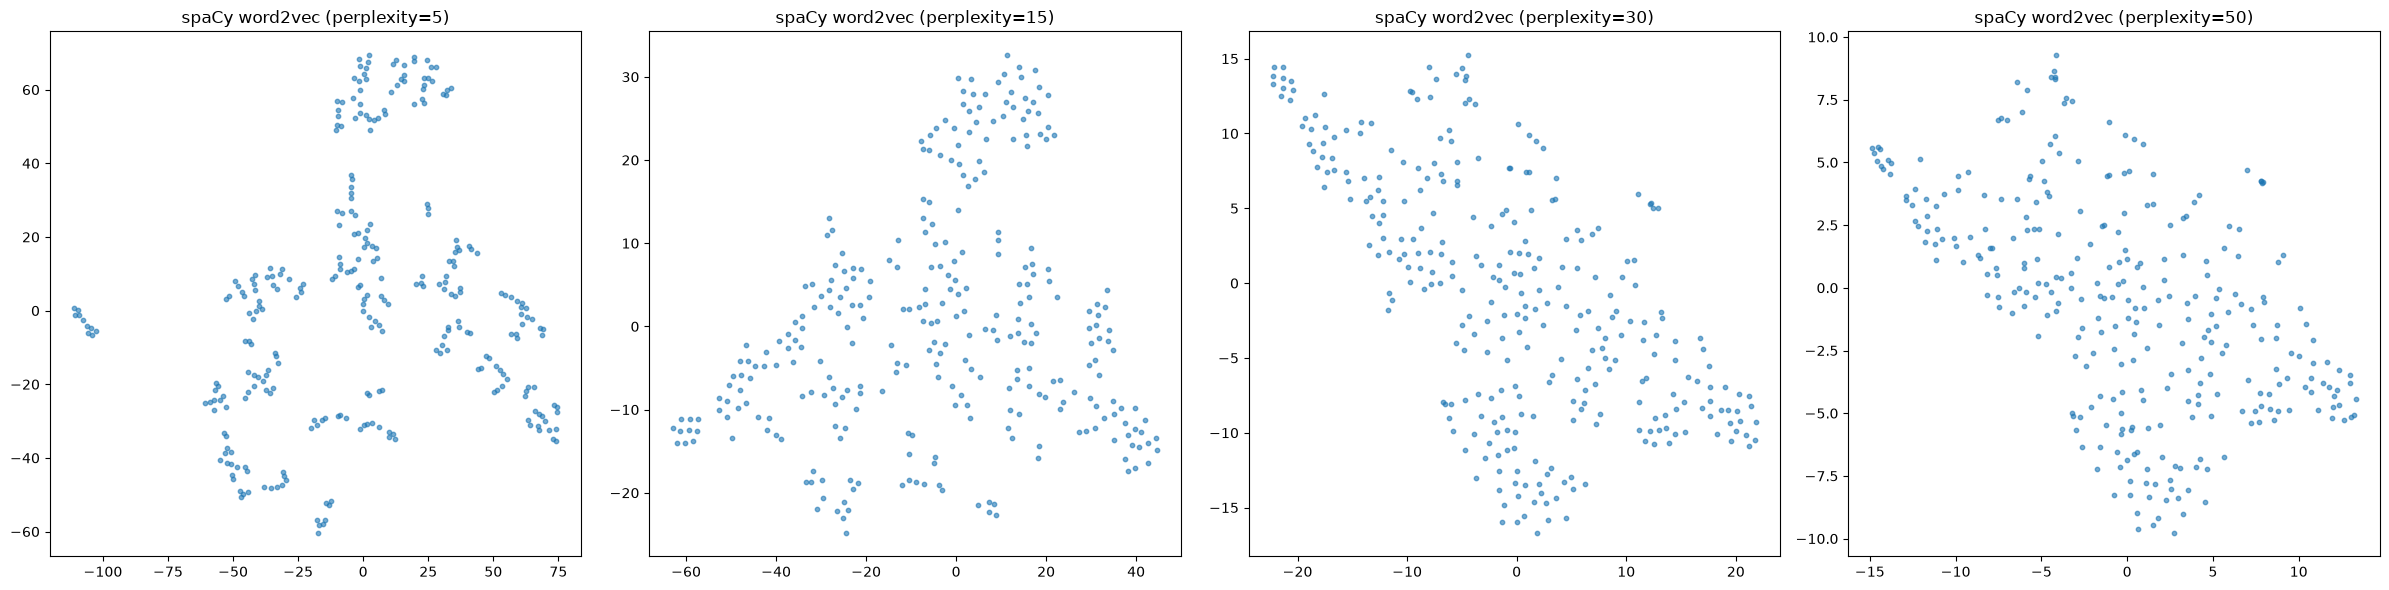

In [30]:
def plot_tsne_perplexities(word2vec_model, perplexities, title_prefix, max_words=300):
    words = list(word2vec_model.wv.index_to_key)[:max_words]
    vectors = np.array([word2vec_model.wv[w] for w in words])

    fig, axes = plt.subplots(1, len(perplexities), figsize=(6 * len(perplexities), 6))
    if len(perplexities) == 1:
        axes = [axes]

    for ax, perp in zip(axes, perplexities):
        tsne = TSNE(
            n_components=2,
            perplexity=min(perp, max(5, len(words) - 1)),
            max_iter=2000,
            init='pca',
            random_state=42,
        )
        coords = tsne.fit_transform(vectors)
        ax.scatter(coords[:, 0], coords[:, 1], s=10, alpha=0.6)
        ax.set_title(f"{title_prefix} (perplexity={perp})")

    plt.tight_layout()
    plt.show()

plot_tsne_perplexities(w2v_spacy, perplexities=[5, 15, 30, 50], title_prefix="spaCy word2vec")


---
## 5. scispaCy



In [35]:
import spacy

# Only override components that house the embedding architecture directly
config_overrides = {
    "components": {
        "tok2vec": {
            "model": {"embed": {"include_static_vectors": False}}
        },
        "ner": {
            "model": {"tok2vec": {"embed": {"include_static_vectors": False}}}
        }
    }
}

# Load the model with the corrected overrides
nlp_scispacy = spacy.load("en_core_sci_sm", config=config_overrides)

# Process  dataframe
docs_scispacy = list(nlp_scispacy.pipe(df_sample['clean_text'].tolist()))

for ent in docs_scispacy[0].ents:
    print(ent.text, "->", ent.label_)

Admission -> ENTITY
Sex -> ENTITY
NEUROSURGERY Allergies -> ENTITY
Patient -> ENTITY
Allergies -> ENTITY
Drugs Attending -> ENTITY
facilities -> ENTITY
Subarachnoid Hemorrhage -> ENTITY
Surgical -> ENTITY
Invasive Procedure -> ENTITY
Placement -> ENTITY
right frontal ventriculostomy -> ENTITY
Coiling -> ENTITY
Aneurysm History of Present Illness -> ENTITY
male -> ENTITY
PMH -> ENTITY
ETOH abuse -> ENTITY
health -> ENTITY
morning -> ENTITY
lightheaded -> ENTITY
says -> ENTITY
feels -> ENTITY
lightheaded -> ENTITY
lightheaded went -> ENTITY
chocolate chips -> ENTITY
loss conciousness -> ENTITY
floor -> ENTITY
patients -> ENTITY
thinks -> ENTITY
kneeling -> ENTITY
witnessed seizure -> ENTITY
scene -> ENTITY
outside -> ENTITY
hospital -> ENTITY
subarachnoid -> ENTITY
blood -> ENTITY
anuersymal -> ENTITY
nature -> ENTITY
transferred -> ENTITY
definitive care -> ENTITY
Medical History -> ENTITY
PMHx -> ENTITY
Alcoholism -> ENTITY
Social History -> ENTITY
Lives -> ENTITY
Dillons -> ENTITY
dri

### 5a. Entity extraction across the cohort

In [36]:
scispacy_entities = []
for doc in docs_scispacy:
    for ent in doc.ents:
        scispacy_entities.append({'text': ent.text, 'label': ent.label_})

df_scispacy_ents = pd.DataFrame(scispacy_entities)
print("Total entities extracted:", len(df_scispacy_ents))
df_scispacy_ents['label'].value_counts()


Total entities extracted: 42842


,count
label,
ENTITY,42842


### 5b. word2vec on the note corpus

In [37]:
scispacy_sentences = [tokenize(doc) for doc in docs_scispacy]

w2v_scispacy = Word2Vec(
    sentences=scispacy_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    seed=42,
)
print("Vocab size:", len(w2v_scispacy.wv))


Vocab size: 3164


### 5c. Tuned t-SNE

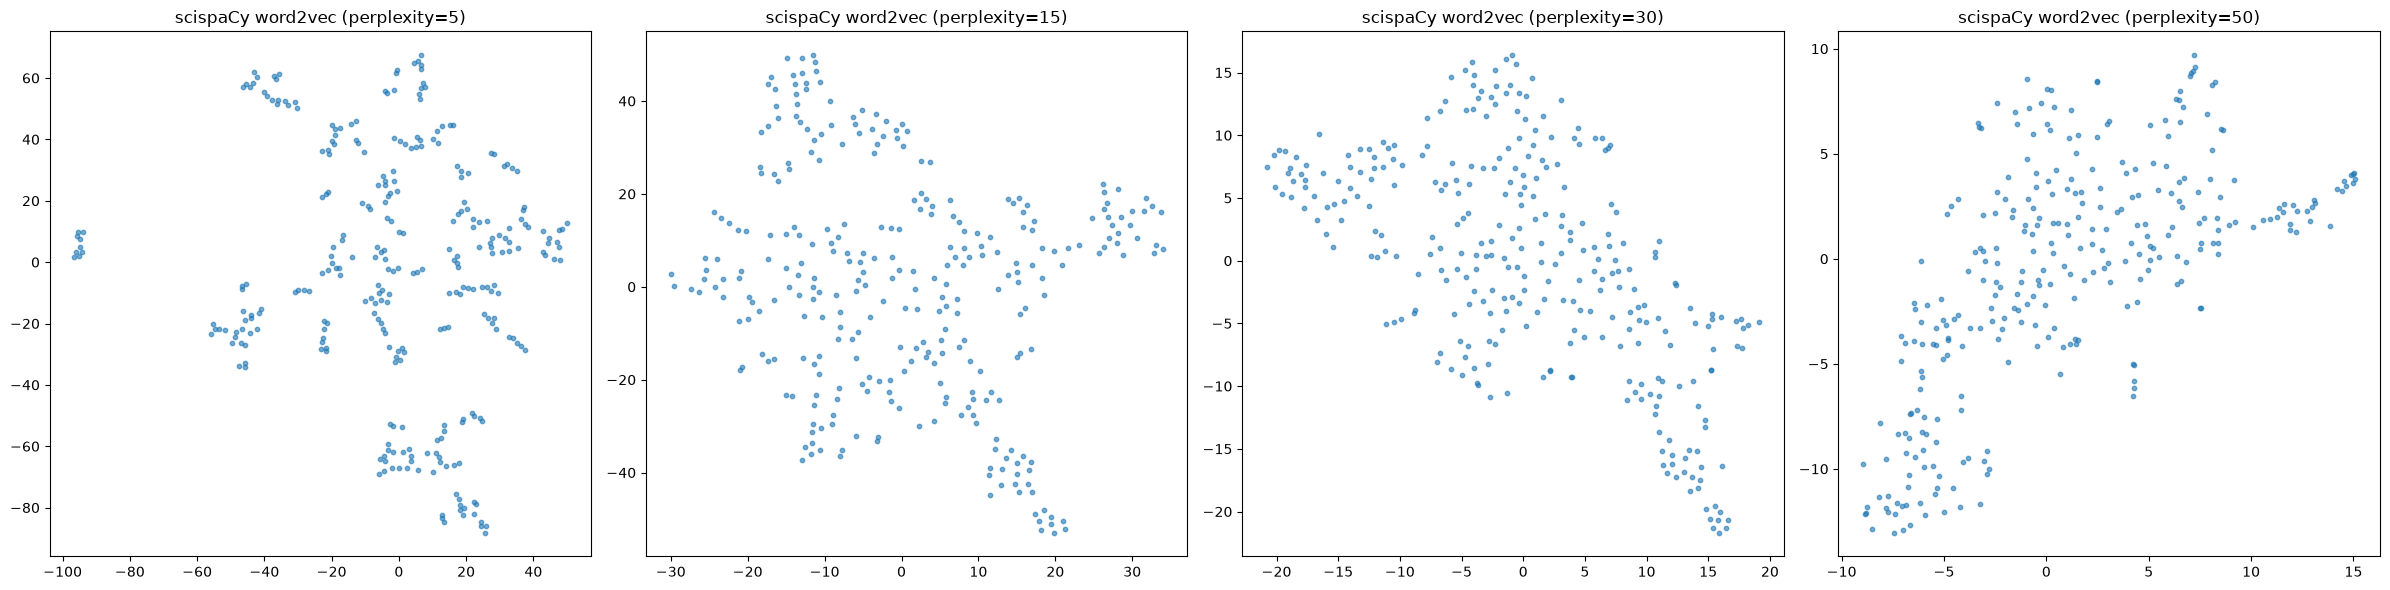

In [38]:
plot_tsne_perplexities(w2v_scispacy, perplexities=[5, 15, 30, 50], title_prefix="scispaCy word2vec")


---
## 6. medspaCy



In [39]:
!pip install -q tqdm

In [40]:
from tqdm.auto import tqdm

# A smaller subsample
MEDSPACY_SAMPLE_SIZE = min(75, len(df_sample))
df_medspacy_sample = df_sample.iloc[:MEDSPACY_SAMPLE_SIZE].reset_index(drop=True)
print(f"Running medspaCy on {len(df_medspacy_sample)} notes "
      f"(out of {len(df_sample)} in the full sample used for spaCy/scispaCy)")

nlp_medspacy = medspacy.load(disable=["parser"])

docs_medspacy = []
for doc in tqdm(
    nlp_medspacy.pipe(df_medspacy_sample['clean_text'].tolist(), batch_size=5),
    total=len(df_medspacy_sample),
    desc="medspaCy processing notes",
):
    docs_medspacy.append(doc)

for ent in docs_medspacy[0].ents:
    print(ent.text, "-> negated:", ent._.is_negated, "| family:", ent._.is_family, "| hypothetical:", ent._.is_hypothetical)


Running medspaCy on 75 notes (out of 100 in the full sample used for spaCy/scispaCy)


medspaCy processing notes:   0%|          | 0/75 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
2026-07-06 02:38:06.369 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=50] [doc 0] Token 4405 'Refills' marked as sentence start (span begin)
2026-07-06 02:38:06.370 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=50] [doc 0] Token 4411 'Acetaminophen' marked as sentence start (span end next token)
2026-07-06 02:38:06.371 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=50] [doc 0] Token 4411 'Acetaminophen' marked as sentence start (span begin)
2026-07-06 02:38:06.371 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=50] [doc 0] Token 4415 'Sig' marked as sentence start (span end next token)
2026-07-06 02:38:06.373 | DEBUG    | PyRuSH.PyRuSHSentencizer:predict:100 - [cpredict_split_gaps|call_id=50] [doc 0] Token 4415 'Sig' marked as sentence start (span begin)
2026-07-06 02:38:06.374 | DEBUG    | PyRuSH.PyR

### 6a. Visualize context attributes (negation, family history, etc.)

In [41]:
visualize_ent(docs_medspacy[0])


### 6b. Entity extraction across the cohort

In [ ]:
medspacy_entities = []
for doc in docs_medspacy:
    for ent in doc.ents:
        medspacy_entities.append({
            'text': ent.text,
            'label': ent.label_,
            'is_negated': ent._.is_negated,
            'is_family': ent._.is_family,
            'is_hypothetical': ent._.is_hypothetical,
        })

df_medspacy_ents = pd.DataFrame(medspacy_entities)
print("Total entities extracted:", len(df_medspacy_ents))
print("\nNegated entities:", df_medspacy_ents['is_negated'].sum())
df_medspacy_ents['label'].value_counts()


### 6c. word2vec on the note corpus

In [ ]:
medspacy_sentences = [tokenize(doc) for doc in docs_medspacy]

w2v_medspacy = Word2Vec(
    sentences=medspacy_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    seed=42,
)
print("Vocab size:", len(w2v_medspacy.wv))


### 6d. Tuned t-SNE

In [ ]:
plot_tsne_perplexities(w2v_medspacy, perplexities=[5, 15, 30, 50], title_prefix="medspaCy word2vec")


---
## 7. Compare & Contrast

Summary table of entity counts and unique labels found by each tool.


In [ ]:
comparison = pd.DataFrame({
    'Tool': ['spaCy', 'scispaCy', 'medspaCy'],
    'Total Entities': [len(df_spacy_ents), len(df_scispacy_ents), len(df_medspacy_ents)],
    'Unique Labels': [df_spacy_ents['label'].nunique(), df_scispacy_ents['label'].nunique(), df_medspacy_ents['label'].nunique()],
})

